# From JWST Galaxy Image to ConvNeXt Embedding

This notebook mirrors `hsc_convnext_embedding.ipynb` but for the JWST side of the same crossmatched galaxy. It also shows how the `resize=True` flag changes the **HSC** preprocessing and what effect that has on the cross-survey embedding comparison — because `resize=True` has **no effect on JWST images**.

**Pipeline overview:**
```
HF dataset row  (same galaxy, two surveys)

  jwst_image['flux']  (7, 96, 96)                hsc_image['flux']  (5, 160, 160)
         │                                                 │
         ▼  band selection (F090W/F277W/F444W)             ▼  band selection (g/r/z)
    (96, 96, 3) float32                               (160, 160, 3) float32
         │                                                 │
         │   ← NO resize block for JWST →                 ├── resize=False: unchanged
         │                                                 └── resize=True:  crop 28×28
         │                                                                    → 96×96
         ▼  percentile norm + uint8                        ▼  percentile norm + uint8
    (96, 96, 3) uint8                             (160,160,3) or (96,96,3) uint8
         │                                                 │
         ▼  AutoImageProcessor  →  (1, 3, 224, 224)        ▼  AutoImageProcessor  →  (1, 3, 224, 224)
         │                                                 │
         ▼  ConvNeXtV2  →  (1, 640, 7, 7)                 ▼  ConvNeXtV2  →  (1, 640, 7, 7)
         │                                                 │
         ▼  mean(dim=(2,3))  →  (1, 640)                   ▼  mean(dim=(2,3))  →  (1, 640)
         │                                                 │
         └──────────── cosine similarity ─────────────────┘
                         (computed twice: with and without resize)
```

## 0. Imports

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoModel, AutoImageProcessor

from pu.zoom import resize_galaxy_to_fit

/global/homes/a/ashodkh/.conda/envs/my_torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


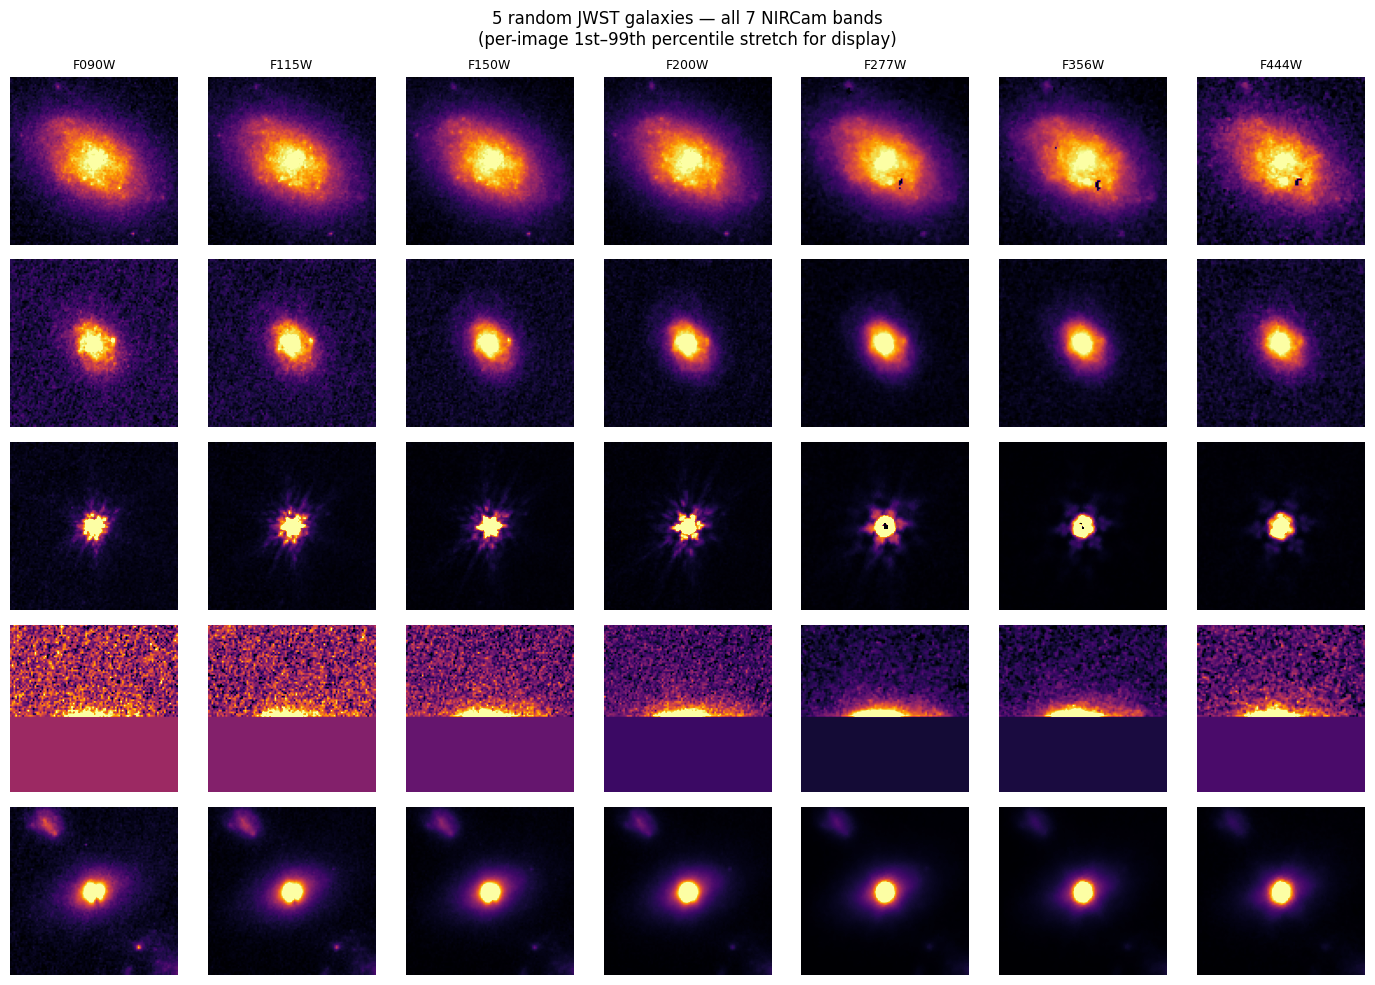

In [14]:
import random

BAND_NAMES = ["F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"]
N_GALAXIES = 5
SEED       = 40

# Pick 5 random row indices from the first 200; sort so we only walk the stream once
random.seed(SEED)
indices = sorted(random.sample(range(200), N_GALAXIES))

sample_rows = []
ds_iter = iter(load_dataset("Smith42/jwst_hsc_crossmatched", split="train", streaming=True))
prev = 0
for idx in indices:
    for _ in range(idx - prev):
        next(ds_iter)
    sample_rows.append(next(ds_iter))
    prev = idx + 1

# Plot: rows = galaxies, columns = bands
fig, axs = plt.subplots(N_GALAXIES, 7, figsize=(14, N_GALAXIES * 2))
for row_i, row in enumerate(sample_rows):
    flux = np.asarray(row["jwst_image"]["flux"], dtype=np.float32)
    for band_i, name in enumerate(BAND_NAMES):
        ax = axs[row_i, band_i]
        img  = flux[band_i]
        vmin = np.nanpercentile(img, 1)
        vmax = np.nanpercentile(img, 99)
        ax.imshow(img, cmap="inferno", origin="lower",
                  vmin=vmin, vmax=(vmax if vmax > vmin else vmin + 1e-6))
        ax.axis("off")
        if row_i == 0:
            ax.set_title(name, fontsize=9)
    axs[row_i, 0].set_ylabel(f"galaxy {indices[row_i]}",
                              fontsize=8, rotation=0, labelpad=48, va="center")

plt.suptitle(
    "5 random JWST galaxies — all 7 NIRCam bands\n"
    "(per-image 1st–99th percentile stretch for display)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 1. Load one row — the same galaxy in both surveys

In [15]:
indices

[8, 62, 117, 134, 148]

In [16]:
HF_DATASET = "Smith42/jwst_hsc_crossmatched"

ds  = load_dataset(HF_DATASET, split="train", streaming=True)
ds_iter = iter(ds)
for _ in range(8):
    next(ds_iter)
row = next(ds_iter)

raw_jwst = np.asarray(row["jwst_image"]["flux"], dtype=np.float32)
raw_hsc  = np.asarray(row["hsc_image"]["flux"],  dtype=np.float32)

print(f"JWST flux shape : {raw_jwst.shape}   (num_bands, height, width)")
print(f"HSC  flux shape : {raw_hsc.shape}")
print()
print(f"JWST value range : [{raw_jwst.min():.3f}, {raw_jwst.max():.3f}]")
print(f"HSC  value range : [{raw_hsc.min():.3f}, {raw_hsc.max():.3f}]")

JWST flux shape : (7, 96, 96)   (num_bands, height, width)
HSC  flux shape : (5, 160, 160)

JWST value range : [-0.258, 14.813]
HSC  value range : [-0.301, 7.847]


## 2. JWST preprocessing: band selection → normalisation → uint8

### 2a. Band selection

JWST has 7 NIRCam bands. Three are selected to span the wavelength range:

| RGB slot | Band | Index | Wavelength |
|---|---|---|---|
| R | F090W | 0 | 0.9 µm |
| G | F277W | 4 | 2.77 µm |
| B | F444W | 6 | 4.44 µm |

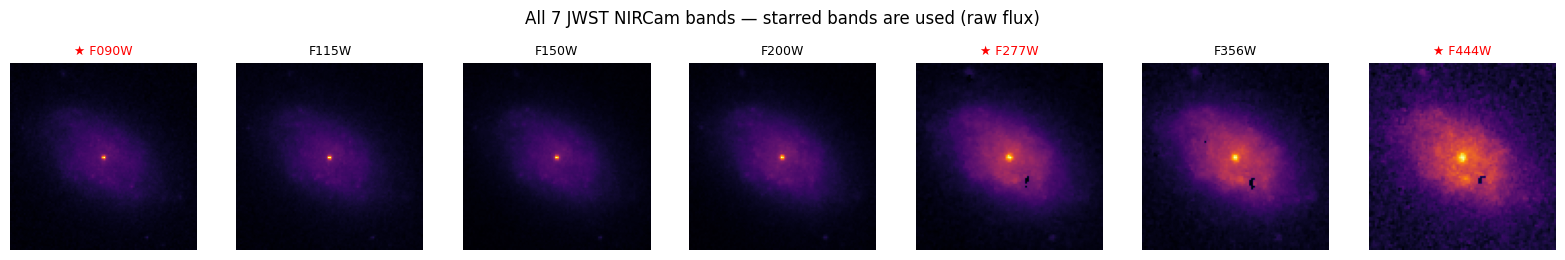

After band selection: (96, 96, 3)


In [17]:
band_names = ["F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"]

fig, axs = plt.subplots(1, 7, figsize=(16, 2.5))
for i, name in enumerate(band_names):
    axs[i].imshow(raw_jwst[i], cmap="inferno", origin="lower")
    label = f"★ {name}" if i in (0, 4, 6) else name
    axs[i].set_title(label, fontsize=9, color=("red" if i in (0, 4, 6) else "black"))
    axs[i].axis("off")
plt.suptitle("All 7 JWST NIRCam bands — starred bands are used (raw flux)", y=1.02)
plt.tight_layout()
plt.show()

arr_jwst = np.stack([raw_jwst[0], raw_jwst[4], raw_jwst[6]], axis=-1)
print(f"After band selection: {arr_jwst.shape}")

### 2b. `resize=True` has no effect on JWST

The `flux_to_pil()` function in `src/pu/preprocess.py` contains a resize block only in the **HSC branch**:

```python
if mode == "hsc":
    arr = np.stack([arr[0], arr[1], arr[3]], axis=-1)   # channel selection
    if (("jwst" in modes) or ...) and resize:            # ← resize block
        arr = resize_galaxy_to_fit(...)
    ...

if mode == "jwst":
    arr = np.stack([arr[0], arr[4], arr[6]], axis=-1)   # channel selection
    # ← no resize block here
    ...
```

The JWST branch has no conditional resize. Whether `resize=True` or `resize=False`, the JWST array passes through unchanged after channel selection. The rationale is that the JWST cutout is already a tight crop around the galaxy; it is the HSC image (which covers a much wider field) that needs to be brought into scale.

### 2c. Percentile normalisation + uint8 cast

JWST RGB uint8 : (96, 96, 3)  dtype=uint8


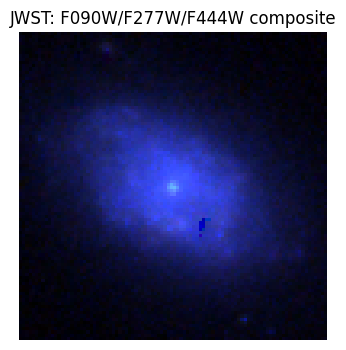

In [18]:
norm_consts_jwst = {
    "f090w": (-0.07078961282968521,  2.4474363327026367),
    "f277w": (-0.017583513632416725, 5.846490383148193),
    "f444w": (-0.0294732004404068,   4.091785907745361),
}

def norm_with_percentiles(chan, v0, v1):
    return ((chan - v0) / (v1 - v0)).clip(0, 1)

arr_jwst_norm = np.stack(
    [norm_with_percentiles(arr_jwst[..., i], *norm_consts_jwst[b])
     for i, b in enumerate(("f090w", "f277w", "f444w"))],
    axis=-1,
)

# Channel flip + uint8  (same final step as HSC)
rgb_jwst = (arr_jwst_norm[..., ::-1] * 255).astype(np.uint8)
print(f"JWST RGB uint8 : {rgb_jwst.shape}  dtype={rgb_jwst.dtype}")

plt.figure(figsize=(4, 4))
plt.imshow(rgb_jwst, origin="lower")
plt.title("JWST: F090W/F277W/F444W composite")
plt.axis("off")
plt.show()

## 3. HSC preprocessing: both paths

We now build both HSC variants so we can compare against JWST later. Full details are in `hsc_convnext_embedding.ipynb`; here we just produce the final uint8 arrays.

In [19]:
norm_consts_hsc = {
    "g": (-0.01787552610039711,  0.35058236330747405),
    "r": (-0.026543444022536278, 0.7422214198112442),
    "z": (-0.057812731899321075, 1.508440258502958),
}

def preprocess_hsc(raw, resize=False):
    """Reproduces flux_to_pil() for mode='hsc', modes=['hsc','jwst']."""
    arr = np.stack([raw[0], raw[1], raw[3]], axis=-1)   # channel selection
    if resize:
        arr = resize_galaxy_to_fit(
            arr, force_extent=(68, 92, 68, 92), target_size=96
        )
    arr = np.stack(
        [norm_with_percentiles(arr[..., i], *norm_consts_hsc[b])
         for i, b in enumerate(("g", "r", "z"))],
        axis=-1,
    )
    return (arr[..., ::-1] * 255).astype(np.uint8)

rgb_hsc_noresize = preprocess_hsc(raw_hsc, resize=False)
rgb_hsc_resized  = preprocess_hsc(raw_hsc, resize=True)

print(f"HSC resize=False : {rgb_hsc_noresize.shape}")
print(f"HSC resize=True  : {rgb_hsc_resized.shape}")

HSC resize=False : (160, 160, 3)
HSC resize=True  : (96, 96, 3)


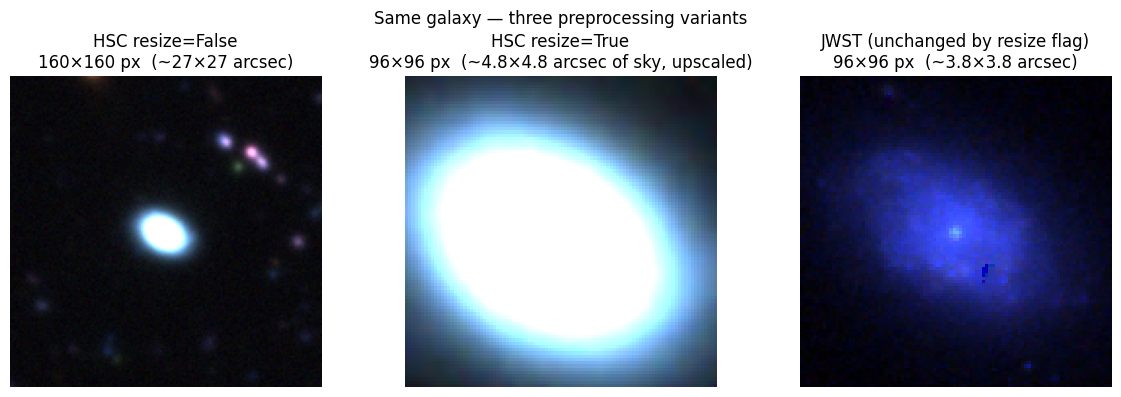

In [20]:
# Side-by-side: all three images at their native sizes before the processor touches them
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(rgb_hsc_noresize, origin="lower")
axs[0].set_title(f"HSC resize=False\n{rgb_hsc_noresize.shape[0]}×{rgb_hsc_noresize.shape[1]} px  "
                 f"(~{rgb_hsc_noresize.shape[0]*0.17:.0f}×{rgb_hsc_noresize.shape[1]*0.17:.0f} arcsec)")
axs[0].axis("off")

axs[1].imshow(rgb_hsc_resized, origin="lower")
axs[1].set_title(f"HSC resize=True\n{rgb_hsc_resized.shape[0]}×{rgb_hsc_resized.shape[1]} px  "
                 f"(~{28*0.17:.1f}×{28*0.17:.1f} arcsec of sky, upscaled)")
axs[1].axis("off")

axs[2].imshow(rgb_jwst, origin="lower")
axs[2].set_title(f"JWST (unchanged by resize flag)\n{rgb_jwst.shape[0]}×{rgb_jwst.shape[1]} px  "
                 f"(~{rgb_jwst.shape[0]*0.04:.1f}×{rgb_jwst.shape[1]*0.04:.1f} arcsec)")
axs[2].axis("off")

plt.suptitle("Same galaxy — three preprocessing variants", fontsize=12)
plt.tight_layout()
plt.show()

The HSC `resize=True` crop covers ~4.8 arcsec of sky; the JWST image covers ~3.8 arcsec. Both are now showing the galaxy at a similar angular scale, as intended. The HSC `resize=False` image covers ~27 arcsec — the galaxy is a small fraction of the frame.

## 4. `AutoImageProcessor` + ConvNeXtV2 forward pass

All three images are processed identically from this point: resize to 224×224, ImageNet normalise, then forward through ConvNeXtV2.

In [21]:
MODEL_NAME = "facebook/convnextv2-nano-22k-224"
processor  = AutoImageProcessor.from_pretrained(MODEL_NAME)
device     = "cuda" if torch.cuda.is_available() else "cpu"
model      = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
print(f"Running on: {device}")

def embed(rgb):
    """Full model pass: uint8 RGB array → (1, 640) embedding."""
    pv = processor(rgb, return_tensors="pt")["pixel_values"].to(device)
    with torch.no_grad():
        lhs = model(pv).last_hidden_state          # (1, 640, 7, 7)
    return lhs.mean(dim=(2, 3)).float()            # (1, 640)

emb_jwst        = embed(rgb_jwst)
emb_hsc_noresize = embed(rgb_hsc_noresize)
emb_hsc_resized  = embed(rgb_hsc_resized)

print(f"JWST embedding          : {emb_jwst.shape}")
print(f"HSC resize=False embed  : {emb_hsc_noresize.shape}")
print(f"HSC resize=True  embed  : {emb_hsc_resized.shape}")

Loading weights: 100%|██████████| 158/158 [00:00<00:00, 979.51it/s, Materializing param=layernorm.weight]                            
ConvNextV2Model LOAD REPORT from: facebook/convnextv2-nano-22k-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running on: cuda
JWST embedding          : torch.Size([1, 640])
HSC resize=False embed  : torch.Size([1, 640])
HSC resize=True  embed  : torch.Size([1, 640])


## 5. Cross-survey embedding comparison

We now have three 640-dimensional vectors. The core question is: does the HSC embedding point in the same direction as the JWST embedding? And does the `resize=True` preprocessing bring them closer together?

Input  to processor : (96, 96, 3)  uint8   range [0, 255]
Output pixel_values : torch.Size([1, 3, 224, 224])  float32  range [-2.12, 2.64]

Processor steps:
  1. Resize shortest edge → 256 px  (= 224 / crop_pct 0.875)
  2. Centre crop          → 224×224
  3. Normalise            → mean=[0.485 0.456 0.406], std=[0.229 0.224 0.225]


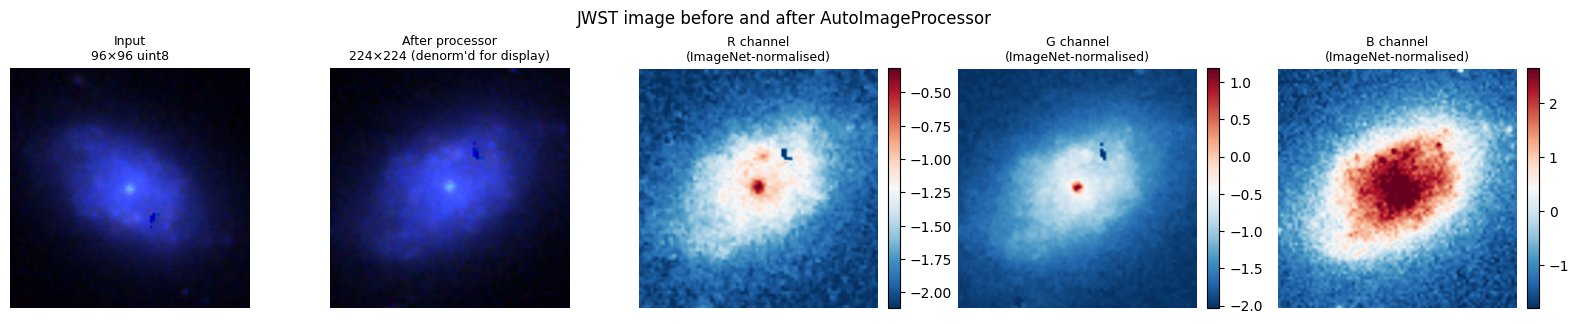

In [22]:
# Show what the AutoImageProcessor does to the JWST image before it enters the model.
# The ConvNextImageProcessor applies three steps in order:
#   1. Resize: scale so the shortest edge = round(224 / crop_pct) = 256 px
#   2. Centre crop: take a 224×224 window from the middle of the 256×256 image
#   3. Normalise: subtract ImageNet mean, divide by ImageNet std (per channel)
#
# Steps 1-2 are a standard torchvision-style resize+crop and are NOT the same as
# a plain bilinear resize to 224×224 directly from the 96×96 input.

pv = processor(rgb_jwst, return_tensors="pt")["pixel_values"]   # (1, 3, 224, 224)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

# Undo normalisation so we can display a perceptually correct image
pv_denormed = np.clip(
    pv[0].permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN,
    0, 1,
)   # (224, 224, 3) in [0, 1]

print(f"Input  to processor : {rgb_jwst.shape}  uint8   range [{rgb_jwst.min()}, {rgb_jwst.max()}]")
print(f"Output pixel_values : {pv.shape}  float32  range [{pv.min():.2f}, {pv.max():.2f}]")
print()
print("Processor steps:")
crop_pct  = 0.875
resize_to = round(224 / crop_pct)
print(f"  1. Resize shortest edge → {resize_to} px  (= 224 / crop_pct {crop_pct})")
print(f"  2. Centre crop          → 224×224")
print(f"  3. Normalise            → mean={IMAGENET_MEAN}, std={IMAGENET_STD}")

fig, axs = plt.subplots(1, 5, figsize=(16, 3.2))

axs[0].imshow(rgb_jwst, origin="lower")
axs[0].set_title(f"Input\n{rgb_jwst.shape[0]}×{rgb_jwst.shape[1]} uint8", fontsize=9)
axs[0].axis("off")

axs[1].imshow(pv_denormed, origin="upper")
axs[1].set_title("After processor\n224×224 (denorm'd for display)", fontsize=9)
axs[1].axis("off")

ch_names = ["R", "G", "B"]
for i in range(3):
    im = axs[i + 2].imshow(pv[0, i].numpy(), cmap="RdBu_r", origin="upper")
    axs[i + 2].set_title(f"{ch_names[i]} channel\n(ImageNet-normalised)", fontsize=9)
    axs[i + 2].axis("off")
    fig.colorbar(im, ax=axs[i + 2], fraction=0.046, pad=0.04)

plt.suptitle("JWST image before and after AutoImageProcessor", fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
cos_noresize = F.cosine_similarity(emb_hsc_noresize, emb_jwst).item()
cos_resized  = F.cosine_similarity(emb_hsc_resized,  emb_jwst).item()
cos_hsc_hsc  = F.cosine_similarity(emb_hsc_noresize, emb_hsc_resized).item()

print(f"Cosine similarity — HSC (resize=False) vs JWST : {cos_noresize:.4f}")
print(f"Cosine similarity — HSC (resize=True)  vs JWST : {cos_resized:.4f}")
print()
print(f"Cosine similarity — HSC (resize=False) vs HSC (resize=True) : {cos_hsc_hsc:.4f}")
print("  (how much the two HSC preprocessings agree with each other)")

Cosine similarity — HSC (resize=False) vs JWST : 0.5954
Cosine similarity — HSC (resize=True)  vs JWST : 0.4606

Cosine similarity — HSC (resize=False) vs HSC (resize=True) : 0.4497
  (how much the two HSC preprocessings agree with each other)


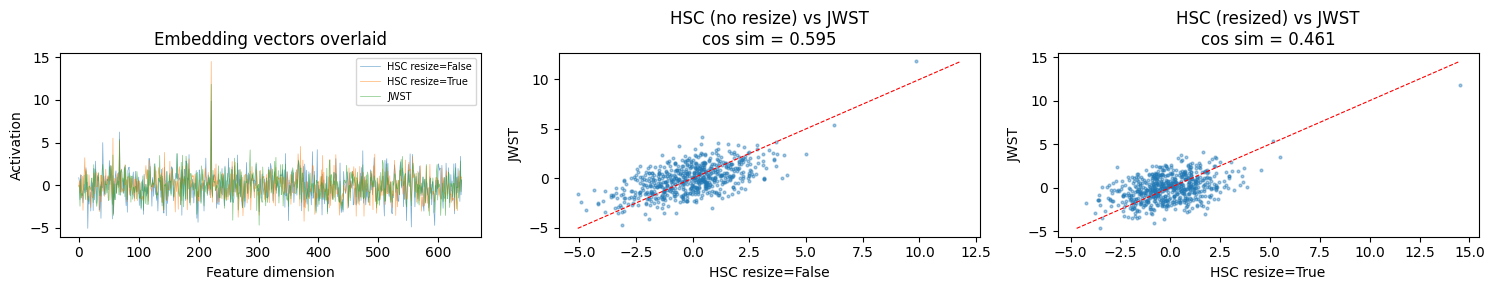

In [24]:
jwst_np = emb_jwst[0].cpu().numpy()
nr_np   = emb_hsc_noresize[0].cpu().numpy()
r_np    = emb_hsc_resized[0].cpu().numpy()

fig, axs = plt.subplots(1, 3, figsize=(15, 3))

# Overlaid traces
axs[0].plot(nr_np,   alpha=0.6, linewidth=0.5, label="HSC resize=False")
axs[0].plot(r_np,    alpha=0.6, linewidth=0.5, label="HSC resize=True")
axs[0].plot(jwst_np, alpha=0.6, linewidth=0.5, label="JWST")
axs[0].set_xlabel("Feature dimension")
axs[0].set_ylabel("Activation")
axs[0].set_title("Embedding vectors overlaid")
axs[0].legend(fontsize=7)

# HSC (no resize) vs JWST
lo = min(nr_np.min(), jwst_np.min())
hi = max(nr_np.max(), jwst_np.max())
axs[1].scatter(nr_np, jwst_np, s=4, alpha=0.4)
axs[1].plot([lo, hi], [lo, hi], "r--", linewidth=0.8)
axs[1].set_xlabel("HSC resize=False")
axs[1].set_ylabel("JWST")
axs[1].set_title(f"HSC (no resize) vs JWST\ncos sim = {cos_noresize:.3f}")

# HSC (resized) vs JWST
lo = min(r_np.min(), jwst_np.min())
hi = max(r_np.max(), jwst_np.max())
axs[2].scatter(r_np, jwst_np, s=4, alpha=0.4)
axs[2].plot([lo, hi], [lo, hi], "r--", linewidth=0.8)
axs[2].set_xlabel("HSC resize=True")
axs[2].set_ylabel("JWST")
axs[2].set_title(f"HSC (resized) vs JWST\ncos sim = {cos_resized:.3f}")

plt.tight_layout()
plt.show()

## Summary

| | JWST | HSC resize=False | HSC resize=True |
|---|---|---|---|
| Raw shape | `(7, 96, 96)` | `(5, 160, 160)` | `(5, 160, 160)` |
| After channel selection | `(96, 96, 3)` | `(160, 160, 3)` | `(160, 160, 3)` |
| After resize | **unchanged** | **unchanged** | `(96, 96, 3)` — 28×28 crop ↑ 96 |
| Sky coverage | ~3.8×3.8 arcsec | ~27×27 arcsec | ~4.8×4.8 arcsec |
| After uint8 | `(96, 96, 3)` | `(160, 160, 3)` | `(96, 96, 3)` |
| After processor | `(1, 3, 224, 224)` | `(1, 3, 224, 224)` | `(1, 3, 224, 224)` |
| After ConvNeXtV2 | `(1, 640, 7, 7)` | `(1, 640, 7, 7)` | `(1, 640, 7, 7)` |
| Embedding | `(1, 640)` | `(1, 640)` | `(1, 640)` |

**Key takeaway:** `resize=True` is a one-sided operation — it crops HSC to match the angular scale of JWST, but leaves JWST untouched. The rationale is that JWST cutouts are already tight around the galaxy, while the HSC cutouts include a wide surrounding sky background. Presenting both surveys at comparable angular scale should give the model more consistent visual context and improve cross-survey embedding alignment. Whether it does at dataset scale is measured by `pu.metrics.mknn` and `pu.metrics.cka` across thousands of galaxy pairs.